# 계층 모형 (Hierarchical Models) — Doing Bayesian Data Analysis, 9장

이 노트북은 Kruschke, *Doing Bayesian Data Analysis* (2판) **9장 Hierarchical Models** 의 핵심을
**Stan / cmdstanpy** 로 재현한 강의용 자료다 (JAGS 미사용). 한 개의 예제를 끝까지 따라가며
**계층 모형(hierarchical model)** 과 **축소(shrinkage)**, 그리고 **베이즈 모델링의 장점**을 이해하는 것이 목표다.

**이 노트북에서 다루는 것**
1. 계층 모형이란 무엇인가 — 동전과 주조소(mint) 비유 (§9.1)
2. 여러 동전이 한 주조소에서 나올 때 (§9.2) — 정보의 상호 공유
3. 베타분포의 최빈값-집중도 재모수화 $(\omega,\kappa)$
4. **Stan 모델** — 그래프 의존구조와 1:1 대응
5. 실제 데이터: Therapeutic Touch 실험 (Rosa et al., 1998)
6. MCMC 샘플링 (cmdstanpy) 과 결과 해석
7. ⭐ **축소(shrinkage)** 와 그 유용성
8. **베이즈 계층 모델링의 장점** 정리

> **실행 안내.** 샘플링 셀은 `cmdstanpy`(Stan)를 우선 사용한다. 실행 환경에 CmdStan 이 설치되어
> 있지 않으면 *동일한 모델*을 표적으로 하는 NumPy 대체 샘플러로 자동 전환되어 그림이 그대로 그려진다.
> CmdStan 이 준비된 컴퓨터(예: `pip install cmdstanpy; python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"`)
> 에서는 실제 Stan(NUTS)이 동작한다.

In [10]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import arviz as az
from scipy.special import betaln, expit, logit
az.style.use("arviz-darkgrid")
print("numpy", np.__version__, "| arviz", az.__version__)

numpy 2.0.1 | arviz 0.21.0


## 1. 계층 모형이란? (§9.1 A Single Coin from a Single Mint)

**계층 모형(hierarchical model)** 은 여러 모수(parameter)들이 있고, *어떤 모수의 그럴듯한 값이 다른
모수의 값에 의미 있게 의존*하도록 구성된 모형이다.

Kruschke 의 비유: **주조소(mint)에서 찍어낸 여러 동전**. 주조소의 편향(bias)을 $\omega$(omega)라 하고
각 동전 $s$ 의 편향을 $\theta_s$ 라 하면, "머리(head)가 잘 나오는 주조소는 머리 편향 동전을 만든다"
— 즉 $\theta_s$ 의 그럴듯한 값이 $\omega$ 에 의존한다. 동전 하나의 편향 추정치는 *주조소 편향의 추정치*에
영향을 받고, 그 주조소 편향은 *모든 동전의 데이터*로부터 추정된다.

동전 하나·주조소 하나인 가장 단순한 경우, 결합 사전분포가 **연쇄적으로 분해(factorization)** 된다:

$$p(\theta,\omega)=p(\theta\mid\omega)\,p(\omega).$$

여기서 $\theta$ 는 $\omega$ 가 주어졌을 때 조건부로 결정되는 *하위(low-level)* 모수, $\omega$ 는 *상위(higher-level)*
모수다. 데이터 $y$ 를 관측하면 베이즈 정리로

$$p(\theta,\omega\mid y)\ \propto\ p(y\mid\theta)\,p(\theta\mid\omega)\,p(\omega).$$

$\omega$ 는 $y$ 에 직접 의존하지 않고 ($y$ 는 $\theta$ 에만 직접 의존), **오직 $\theta$ 를 통해서** 데이터의 영향을 받는다.
이 "사슬 같은 의존 구조"가 계층 모형의 본질이다.

## 2. 여러 동전이 한 주조소에서 (§9.2 Multiple Coins from a Single Mint)

이제 같은 주조소에서 나온 동전이 여러 개($s=1,\dots,S$)라고 하자. 각 동전은 자기 데이터 $z_s$
(성공 횟수, 예: 앞면 수)와 시행수 $N_s$ 를 가진다. 모형은

$$
\begin{aligned}
z_s \mid \theta_s &\sim \text{Binomial}(N_s,\ \theta_s) && \text{(각 동전의 가능도)}\\
\theta_s \mid \omega,\kappa &\sim \text{Beta}(\dots) && \text{(공통 주조소 분포)}\\
\omega,\ \kappa &\sim (\text{사전분포}) && \text{(주조소 수준 모수)}
\end{aligned}
$$

핵심 직관: **모든 동전의 데이터가 함께 $\omega$ 를 추정**하고, 그렇게 추정된 $\omega$ 가 다시 각 $\theta_s$ 를
끌어당긴다. 즉 동전들은 서로의 추정치에 정보를 빌려준다(*borrowing strength*). 데이터가 적은 동전일수록
이 공유 정보의 도움을 더 크게 받는다 — 뒤에서 볼 **축소(shrinkage)** 의 원천이다.

## 3. 베타분포의 재모수화: 최빈값 $\omega$ 와 집중도 $\kappa$

$\theta_s$ 가 따르는 공통 분포를 베타분포로 두되, 표준적인 $(a,b)$ 대신 **최빈값(mode) $\omega$** 와
**집중도(concentration) $\kappa$** 로 재모수화한다(직관적이기 때문):

$$
\theta_s \mid \omega,\kappa \ \sim\ \text{Beta}\big(\underbrace{\omega(\kappa-2)+1}_{a},\ \underbrace{(1-\omega)(\kappa-2)+1}_{b}\big),\qquad \kappa>2 .
$$

- $\omega\in(0,1)$ : 베타분포의 **최빈값** — 주조소(집단)의 대표 편향.
- $\kappa$ : **집중도** — 클수록 $\theta_s$ 들이 $\omega$ 근처에 빽빽이 모인다(=동전들이 서로 비슷). 작을수록 흩어진다.

상위 모수의 사전분포:

$$\omega \sim \text{Beta}(1,1)\ (\text{균일}),\qquad
\kappa-2 \sim \text{Gamma}(0.01,\ 0.01)\ (\text{평균}=1,\ \text{표준편차}=10,\ \text{매우 약한 정보}).$$

$\kappa$ 를 $\kappa-2$ 의 감마분포로 둔 이유: 감마분포는 $[0,\infty)$ 를 덮지만 $\kappa$ 는 2 이상이어야
($a,b\ge1$ 이 되어 단봉/유효) 하므로 2만큼 평행이동한다. 아래에서 $\omega,\kappa$ 가 베타분포 모양을
어떻게 바꾸는지 눈으로 확인하자.

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\2278095623.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


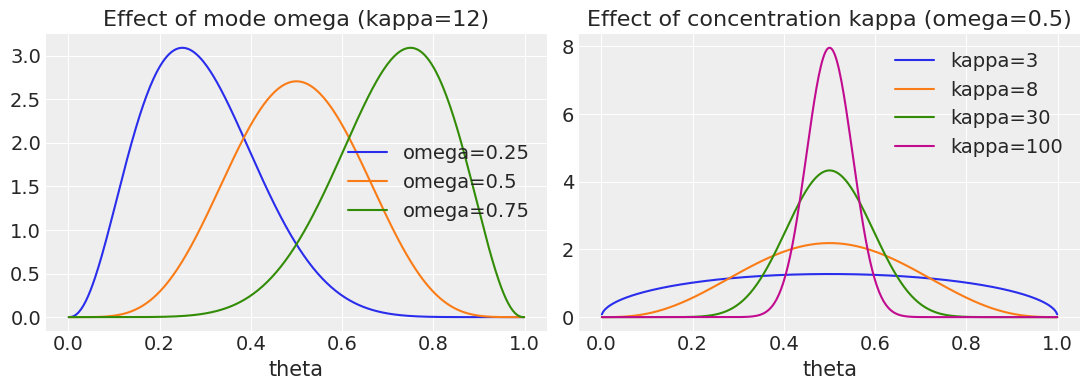

In [11]:
# omega, kappa 가 theta 의 집단 분포(Beta) 모양을 어떻게 바꾸는가
from scipy.stats import beta as beta_dist
xs=np.linspace(1e-3,1-1e-3,400)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for w in [0.25,0.5,0.75]:
    k=12
    a=w*(k-2)+1; b=(1-w)*(k-2)+1
    axes[0].plot(xs,beta_dist.pdf(xs,a,b),label=f"omega={w}")
axes[0].set_title("Effect of mode omega (kappa=12)"); axes[0].set_xlabel("theta"); axes[0].legend()
for k in [3,8,30,100]:
    w=0.5; a=w*(k-2)+1; b=(1-w)*(k-2)+1
    axes[1].plot(xs,beta_dist.pdf(xs,a,b),label=f"kappa={k}")
axes[1].set_title("Effect of concentration kappa (omega=0.5)"); axes[1].set_xlabel("theta"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Stan 모델 — 그래프 의존구조와 1:1 대응

계층 다이어그램의 **화살표 하나하나가 Stan 코드 한 줄**에 대응한다. 아래 모델은 위 수식을 그대로 옮긴 것이다.

| 수학 (math) | Stan |
|---|---|
| $z_s \sim \text{Binomial}(N_s,\theta_s)$ | `z ~ binomial(N, theta);` |
| $\theta_s \sim \text{Beta}(\omega(\kappa-2)+1,(1-\omega)(\kappa-2)+1)$ | `theta ~ beta(omega*(kappa-2)+1, (1-omega)*(kappa-2)+1);` |
| $\omega \sim \text{Beta}(1,1)$ | `omega ~ beta(1,1);` |
| $\kappa-2 \sim \text{Gamma}(0.01,0.01)$ | `kappaMinusTwo ~ gamma(0.01, 0.01);` |
| $\kappa=(\kappa-2)+2$ | `kappa = kappaMinusTwo + 2;` |

In [12]:
stan_code = r"""
data {
  int<lower=1> Nsubj;                 // 동전(=피험자) 수
  array[Nsubj] int<lower=0> z;        // 각자 성공(정답) 횟수
  array[Nsubj] int<lower=1> N;        // 각자 시행 횟수
}
parameters {
  real<lower=0, upper=1> omega;       // 집단 최빈값(group mode)
  real<lower=0> kappaMinusTwo;        // kappa - 2  (>= 0)
  vector<lower=0, upper=1>[Nsubj] theta;  // 개인별 편향 theta_s
}
transformed parameters {
  real<lower=2> kappa = kappaMinusTwo + 2;   // 집중도
}
model {
  omega ~ beta(1, 1);                                 // 균일 사전
  kappaMinusTwo ~ gamma(0.01, 0.01);                  // 평균 1, sd 10 (약한 정보)
  theta ~ beta(omega*(kappa-2)+1, (1-omega)*(kappa-2)+1);  // 공통 베타 (계층 사전)
  z ~ binomial(N, theta);                             // 가능도
}
"""
with open("therapeutic_touch.stan","w") as f: f.write(stan_code)
print(stan_code)


data {
  int<lower=1> Nsubj;                 // 동전(=피험자) 수
  array[Nsubj] int<lower=0> z;        // 각자 성공(정답) 횟수
  array[Nsubj] int<lower=1> N;        // 각자 시행 횟수
}
parameters {
  real<lower=0, upper=1> omega;       // 집단 최빈값(group mode)
  real<lower=0> kappaMinusTwo;        // kappa - 2  (>= 0)
  vector<lower=0, upper=1>[Nsubj] theta;  // 개인별 편향 theta_s
}
transformed parameters {
  real<lower=2> kappa = kappaMinusTwo + 2;   // 집중도
}
model {
  omega ~ beta(1, 1);                                 // 균일 사전
  kappaMinusTwo ~ gamma(0.01, 0.01);                  // 평균 1, sd 10 (약한 정보)
  theta ~ beta(omega*(kappa-2)+1, (1-omega)*(kappa-2)+1);  // 공통 베타 (계층 사전)
  z ~ binomial(N, theta);                             // 가능도
}



## 5. 데이터: Therapeutic Touch 실험 (Rosa et al., 1998)

- **Therapeutic touch(치료적 손길)** 는 시술자가 환자를 직접 만지지 않고 손으로 "에너지장"을 다룬다는
간호 기법이다. 
- Rosa 등(1998)은 핵심 주장 — *시술자가 인체의 에너지장을 감지할 수 있는가* — 를 검증했다.
- 시술자는 칸막이 너머로 양손을 내밀고, 실험자가 동전을 던져 한쪽 손 위에 자기 손을 올린다. 
- 시술자는 어느 손 위에 실험자의 손이 있는지 *맞히기*만 하면 된다. 감지 능력이 있다면 정답률이 우연(0.5)보다 높아야 한다.

- **28명**의 시술자가 각각 **10회**씩 시행했다. 
- 데이터는 0/1(정답 여부)의 긴 형식이며, 피험자는 성적이 낮은 순으로 정렬되어 있다(S01 최저, S28 최고).

In [13]:
df = pd.read_csv("TherapeuticTouchData.csv")
# 피험자별 성공수 z_s, 시행수 N_s 로 집계
g = df.groupby("s")["y"].agg(["sum","count"]).rename(columns={"sum":"z","count":"N"})
g["proportion"] = g["z"]/g["N"]
z = g["z"].to_numpy(); N = g["N"].to_numpy(); subj = g.index.to_list()
Nsubj = len(subj)
print(f"피험자 수 Nsubj = {Nsubj},  총 시행 = {N.sum()},  총 정답 = {z.sum()}  (전체 비율 {z.sum()/N.sum():.3f})")
g.head()

피험자 수 Nsubj = 28,  총 시행 = 280,  총 정답 = 123  (전체 비율 0.439)


,z,N,proportion
s,,,
S01,1,10,0.1
S02,2,10,0.2
S03,3,10,0.3
S04,3,10,0.3
S05,3,10,0.3


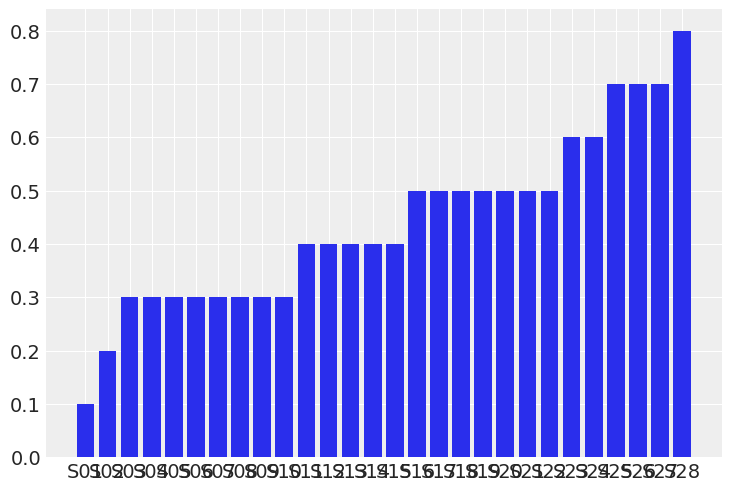

In [20]:
plt.bar(subj, g["proportion"], color="C0", label="data");

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\1348774129.py:7: UserWarning: The figure layout has changed to tight
  ax.legend(); plt.tight_layout(); plt.show()


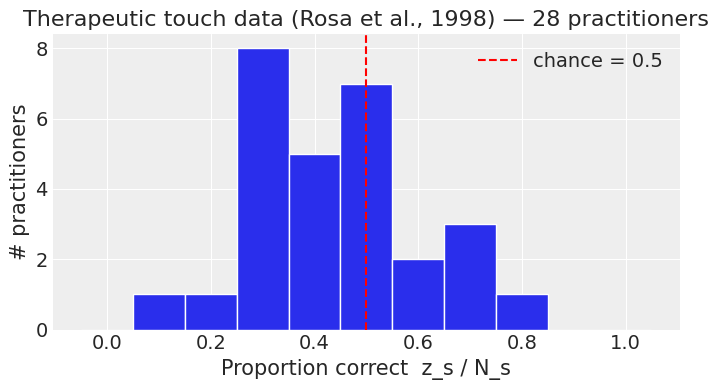

In [14]:
# Figure 9.9 재현: 28명의 정답 비율 히스토그램
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(g["proportion"], bins=np.arange(-0.05,1.06,0.1), color="C0", edgecolor="white")
ax.axvline(0.5, color="red", ls="--", label="chance = 0.5")
ax.set_xlabel("Proportion correct  z_s / N_s"); ax.set_ylabel("# practitioners")
ax.set_title("Therapeutic touch data (Rosa et al., 1998) — 28 practitioners")
ax.legend(); plt.tight_layout(); plt.show()

## 6. MCMC 샘플링 (cmdstanpy)

총 추정 모수는 $28$ 개의 $\theta_s$ + $\omega$ + $\kappa$ = **30개**. Stan(NUTS)으로 4개 체인을 돌린다.
CmdStan 이 없으면 같은 사후분포를 표적으로 하는 NumPy 대체 샘플러(Metropolis)로 자동 전환된다.

In [15]:
stan_data = {"Nsubj": int(Nsubj), "z": z.astype(int).tolist(), "N": N.astype(int).tolist()}
idata=None; backend=None

# ---- 1순위: 실제 Stan ----
try:
    from cmdstanpy import CmdStanModel
    model = CmdStanModel(stan_file="therapeutic_touch.stan")
    fit = model.sample(data=stan_data, chains=4, iter_warmup=1000, iter_sampling=1000,
                       seed=11, adapt_delta=0.95, show_progress=False)
    idata = az.from_cmdstanpy(fit, coords={"subject": subj},
                              dims={"theta": ["subject"]})
    backend = "Stan / cmdstanpy (NUTS)"
    print(fit.diagnose())
except Exception as e:
    print("[info] CmdStan 사용 불가 -> NumPy 대체 샘플러(Metropolis)로 전환")
    print("       reason:", str(e).splitlines()[0][:160])

# ---- 대체: 동일 모델 표적 Metropolis (체인 벡터화) ----
if idata is None:
    def log_target(P, z, N):
        # P: (C, ndim) = [logit(omega), log(kappa-2), logit(theta_1..S)]
        a_om=P[:,0]; l_k=P[:,1]; t=P[:,2:]
        om=expit(a_om); km=np.exp(l_k); th=expit(t)
        lp = np.log(om)+np.log1p(-om)                      # omega~Beta(1,1) + logit Jacobian
        lp += (0.01-1)*np.log(km) - 0.01*km + l_k          # (kappa-2)~Gamma(.01,.01) + log Jacobian
        a=(om*km+1.0)[:,None]; b=((1-om)*km+1.0)[:,None]
        lp += np.sum((a-1)*np.log(th)+(b-1)*np.log1p(-th)-betaln(a,b), axis=1)  # theta~Beta(a,b)
        lp += np.sum(np.log(th)+np.log1p(-th), axis=1)     # logit Jacobian for each theta
        lp += np.sum(z*np.log(th)+(N-z)*np.log1p(-th), axis=1)  # Binomial likelihood
        return lp
    def metropolis(z, N, n_chains=4, n_iter=20000, burn=8000, thin=4, seed=11):
        rng=np.random.default_rng(seed); S=len(z); ndim=2+S
        P=np.tile(np.concatenate([[0.0,np.log(10.0)], logit((z+1)/(N+2))]),(n_chains,1))
        P += rng.normal(0,0.1,P.shape)
        step=np.concatenate([[0.3,0.4], np.full(S,0.5)]); cur=log_target(P,z,N)
        acc=np.zeros(ndim); keep=[]
        for it in range(n_iter):
            for j in range(ndim):
                prop=P.copy(); prop[:,j]+=rng.normal(0,step[j],n_chains)
                lp=log_target(prop,z,N); a=np.log(rng.random(n_chains))<lp-cur
                P[a]=prop[a]; cur[a]=lp[a]; acc[j]+=a.mean()
            if it<burn and it%500==499:
                r=acc/(it+1); step*=np.where(r>0.4,1.1,np.where(r<0.2,0.9,1.0))
            if it>=burn and (it-burn)%thin==0: keep.append(P.copy())
        K=np.array(keep).transpose(1,0,2)   # (chains, draws, ndim)
        return K
    K = metropolis(z, N)
    omega_d = expit(K[:,:,0]); kappa_d = np.exp(K[:,:,1])+2.0; theta_d = expit(K[:,:,2:])
    idata = az.from_dict(posterior={"omega":omega_d,"kappa":kappa_d,"theta":theta_d},
                         coords={"subject":subj}, dims={"theta":["subject"]})
    backend = "NumPy fallback (Metropolis, same model)"

print("\nBackend used:", backend)

15:13:05 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\SimStudy\gelman2012\therapeutic_touch.stan to exe file C:\Users\yongduek\Downloads\SimStudy\gelman2012\therapeutic_touch.exe
15:13:21 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\SimStudy\gelman2012\therapeutic_touch.exe
15:13:21 - cmdstanpy - INFO - CmdStan start processing
15:13:21 - cmdstanpy - INFO - Chain [1] start processing
15:13:21 - cmdstanpy - INFO - Chain [2] start processing
15:13:21 - cmdstanpy - INFO - Chain [3] start processing
15:13:21 - cmdstanpy - INFO - Chain [4] start processing
15:13:22 - cmdstanpy - INFO - Chain [1] done processing
15:13:22 - cmdstanpy - INFO - Chain [2] done processing
15:13:22 - cmdstanpy - INFO - Chain [3] done processing
15:13:23 - cmdstanpy - INFO - Chain [4] done processing
15:13:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'therapeutic_touch.

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.23, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.


Backend used: Stan / cmdstanpy (NUTS)


In [16]:
# 수렴 진단 + 사후 요약 (R-hat, ESS)
az.summary(idata, var_names=["omega","kappa","theta"], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
omega,0.437,0.036,0.367,0.502,0.001,0.001,1097.367,2042.661,1.002
kappa,62.420,66.353,3.963,180.491,3.900,5.004,229.148,582.159,1.009
theta[S01],0.365,0.085,0.204,0.524,0.003,0.002,903.776,1598.895,1.003
theta[S02],0.387,0.080,0.233,0.533,0.002,0.002,1257.235,1601.120,1.000
theta[S03],0.410,0.078,0.253,0.548,0.002,0.002,2476.184,2349.813,1.001
theta[S04],0.411,0.076,0.258,0.545,0.001,0.002,2766.956,2122.733,1.001
theta[S05],0.410,0.077,0.259,0.550,0.002,0.002,2107.192,2126.590,1.005
theta[S06],0.410,0.079,0.249,0.550,0.002,0.002,2122.799,2366.885,1.001
theta[S07],0.409,0.078,0.258,0.551,0.002,0.002,2450.568,1847.845,1.003
theta[S08],0.410,0.076,0.259,0.550,0.002,0.002,2431.657,2241.770,1.001


## 7. 결과 해석

아래 그림은 집단 최빈값 $\omega$, 집중도 $\kappa$, 그리고 대표 개인 $\theta_1$(최저), $\theta_{14}$(중앙),
$\theta_{28}$(최고)의 주변 사후분포다. 빨간 점선은 우연 수준 0.5.

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\2712465598.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


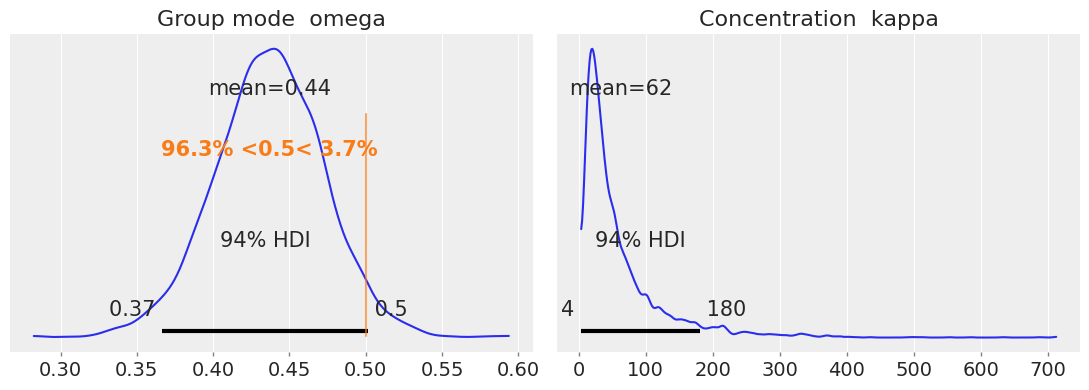

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\2712465598.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


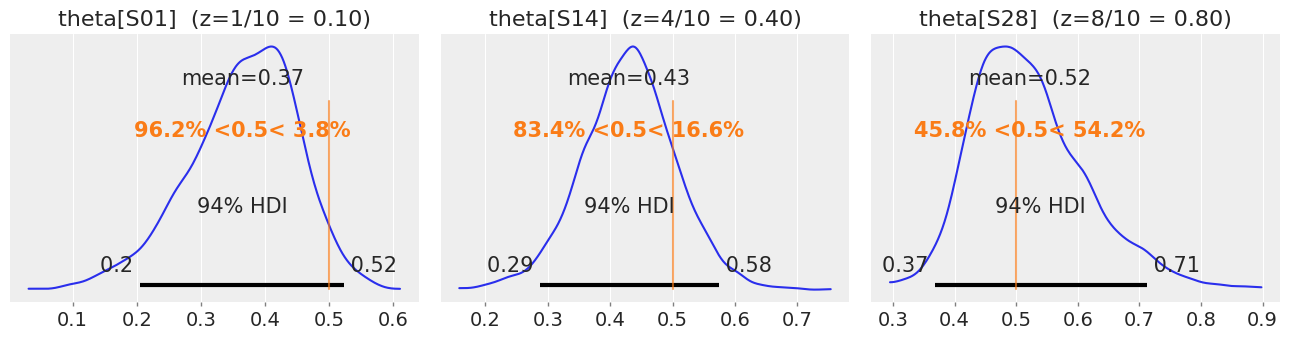

In [17]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
az.plot_posterior(idata, var_names=["omega"], ref_val=0.5, ax=axes[0])
axes[0].set_title("Group mode  omega")
az.plot_posterior(idata, var_names=["kappa"], ax=axes[1]); axes[1].set_title("Concentration  kappa")
plt.tight_layout(); plt.show()

# 대표 개인 3명
sel = [0,13,27]
fig, axes = plt.subplots(1,3, figsize=(13,3.5))
for ax,i in zip(axes,sel):
    az.plot_posterior(idata.posterior["theta"].isel(subject=i), ref_val=0.5, ax=ax)
    ax.set_title(f"theta[{subj[i]}]  (z={z[i]}/{N[i]} = {z[i]/N[i]:.2f})")
plt.tight_layout(); plt.show()

- $\omega$ 의 최빈값은 0.5보다 작고 95% HDI 가 0.5를 포함한다 → **시술자 집단이 우연보다 잘 감지한다고 결론지을 수 없다.** 
- 개인들도 마찬가지다. 흥미로운 점은 개인 추정치가 자기 데이터에서 멀어진다는 것:
  - $\theta_1$ 은 데이터가 $1/10=0.1$ 인데 사후 최빈값이 $\approx0.39$ 로 **위로** 당겨지고, 
  - $\theta_{28}$ 은 $8/10=0.8$ 인데 $\approx0.49$ 로 **아래로** 당겨진다. 이것이 축소효과(shrinkage effect)다.

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\289723662.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


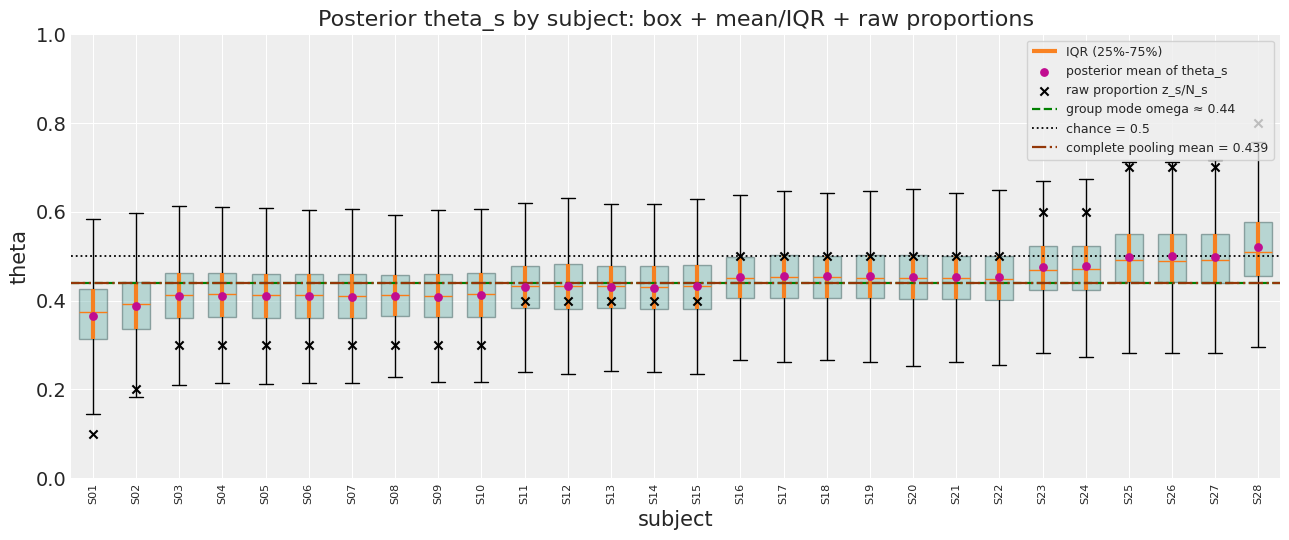

In [26]:
# Vertical posterior distribution plots for all theta_s
# Set plot_kind to "violin" or "box"
plot_kind = "violin"
plot_kind = "box"

theta_da = idata.posterior["theta"].stack(sample=("chain", "draw"))
theta_draws = [theta_da.isel(subject=i).to_numpy() for i in range(Nsubj)]
raw = z / N

# Complete pooling estimate: one shared theta across all subjects
complete_pooling_mean = z.sum() / N.sum()

# Requested group mode reference (approximately 0.44)
omega_ref = 0.44

fig, ax = plt.subplots(figsize=(13, 5.5))
positions = np.arange(1, Nsubj + 1)

if plot_kind == "violin":
    parts = ax.violinplot(
        theta_draws,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor("#76B7B2")
        body.set_edgecolor("#2F4F4F")
        body.set_alpha(0.45)
elif plot_kind == "box":
    parts = ax.boxplot(
        theta_draws,
        positions=positions,
        widths=0.65,
        patch_artist=True,
        showfliers=False,
    )
    for patch in parts["boxes"]:
        patch.set_facecolor("#76B7B2")
        patch.set_edgecolor("#2F4F4F")
        patch.set_alpha(0.45)
else:
    raise ValueError('plot_kind must be either "violin" or "box"')

# Mean and IQR overlays for each subject
theta_mean = np.array([d.mean() for d in theta_draws])
theta_q25 = np.array([np.quantile(d, 0.25) for d in theta_draws])
theta_q75 = np.array([np.quantile(d, 0.75) for d in theta_draws])
ax.vlines(positions, theta_q25, theta_q75, color="C1", lw=3, alpha=0.95, label="IQR (25%-75%)")
ax.scatter(positions, theta_mean, color="C3", s=28, zorder=3, label="posterior mean of theta_s")

# Raw proportions per subject
ax.scatter(positions, raw, color="black", marker="x", s=35, zorder=3, label="raw proportion z_s/N_s")

# Horizontal reference lines
ax.axhline(omega_ref, color="green", ls="--", lw=1.6, label=f"group mode omega ≈ {omega_ref:.2f}")
ax.axhline(0.5, color="black", ls=":", lw=1.3, label="chance = 0.5")
ax.axhline(complete_pooling_mean, color="C4", ls="-.", lw=1.6,
           label=f"complete pooling mean = {complete_pooling_mean:.3f}")

ax.set_xticks(positions)
ax.set_xticklabels(subj, rotation=90, fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel("theta")
ax.set_xlabel("subject")
ax.set_title(f"Posterior theta_s by subject: {plot_kind} + mean/IQR + raw proportions")
ax.legend(loc="upper right", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

The **complete pooling mean** and **group mode omega** $\omega$ are conceptually different quantities and cannot be the same in theory.
- can be the same if there are infinitely many data points

## 8. ⭐ 축소 (Shrinkage) 와 그 유용성 (§9.3)

계층 모형에서 하위 모수($\theta_s$) 추정치들은, 상위 분포가 없을 때보다 **서로 가깝게 당겨진다.**
이를 **축소(shrinkage)** 라 한다. 아래 그림은 각 개인의 *원자료 비율* $z_s/N_s$ 와 *사후평균* $\theta_s$ 를
잇는다 — 모두 집단 최빈값 $\omega$ 쪽으로 끌려옴을 한눈에 볼 수 있다.

C:\Users\yongduek\AppData\Local\Temp\ipykernel_41072\215694789.py:15: UserWarning: The figure layout has changed to tight
  ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


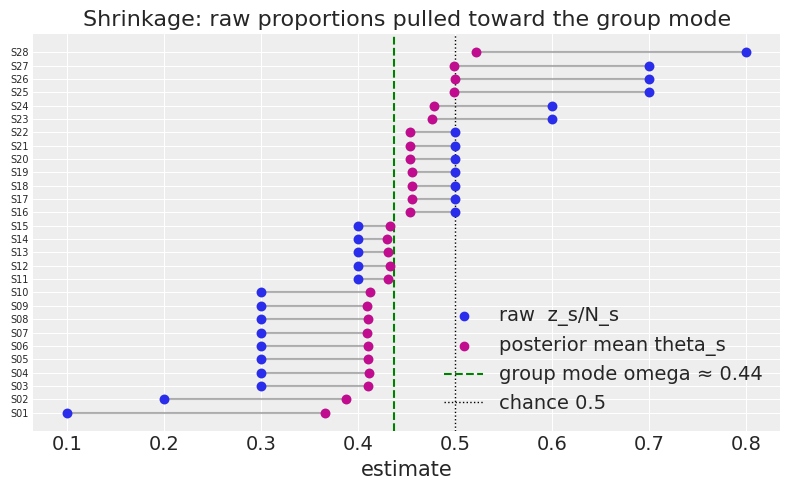

원자료 비율의 표준편차      : 0.163
사후평균 theta_s 의 표준편차 : 0.037  (← 더 작다 = 분산 축소)


In [18]:
post_theta = idata.posterior["theta"].mean(dim=("chain","draw")).to_numpy()
omega_mean = float(idata.posterior["omega"].mean())
raw = z/N
order = np.argsort(raw)

fig, ax = plt.subplots(figsize=(8,5))
for k,i in enumerate(order):
    ax.plot([raw[i], post_theta[i]], [k,k], "o-", color="grey", alpha=0.6)
ax.scatter(raw[order], range(Nsubj), color="C0", label="raw  z_s/N_s", zorder=3)
ax.scatter(post_theta[order], range(Nsubj), color="C3", label="posterior mean theta_s", zorder=3)
ax.axvline(omega_mean, color="green", ls="--", label=f"group mode omega ≈ {omega_mean:.2f}")
ax.axvline(0.5, color="black", ls=":", lw=1, label="chance 0.5")
ax.set_yticks(range(Nsubj)); ax.set_yticklabels([subj[i] for i in order], fontsize=7)
ax.set_xlabel("estimate"); ax.set_title("Shrinkage: raw proportions pulled toward the group mode")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

print(f"원자료 비율의 표준편차      : {raw.std():.3f}")
print(f"사후평균 theta_s 의 표준편차 : {post_theta.std():.3f}  (← 더 작다 = 분산 축소)")

### 축소는 왜 일어나는가 (직관 + MLE 논증)

각 하위 모수 $\theta_s$ 의 추정은 **두 출처**의 영향을 동시에 받는다:
(1) 그 개인에게 직접 딸린 데이터 $z_s/N_s$, (2) 모든 데이터가 함께 결정한 상위 모수 $\omega,\kappa$.
상위 모수는 *모든* 데이터의 영향을 받으므로, 개인 추정치는 *다른 모든 개인의 데이터*로부터도 간접적으로
영향을 받아 집단 쪽으로 당겨진다.

축소는 베이즈 추정만의 현상이 아니라 **계층 구조 자체의 논리적 귀결**이다. 데이터 한 점의 가능도는

$$p(z_s\mid\theta_s,\omega,\kappa)=\underbrace{\text{Binomial}(z_s\mid N_s,\theta_s)}_{\theta_s \to z_s/N_s\ \text{쪽}}\cdot
\underbrace{\text{Beta}(\theta_s\mid\omega(\kappa-2)+1,\dots)}_{\theta_s \to \omega\ \text{쪽}} .$$

두 항의 곱을 최대화하는 $\theta_s$ 는 데이터 비율 $z_s/N_s$ 와 집단 최빈값 $\omega$ **사이**에 놓인다 →
$\theta_s$ 가 $\omega$ 쪽으로 당겨진다.

### 축소가 유용한 이유

- **표집 잡음에 덜 흔들린다.** 축소된 추정치는 표본 우연(sampling noise)의 영향이 작다. $1/10$ 같은
  극단값은 운일 가능성이 큰데, 27명의 정보가 이를 합리적으로 완화한다(과적합 방지, regularization).
- **정보의 차용(borrowing strength).** 데이터가 적은 개인일수록 집단 정보의 도움을 더 받는다(축소가 큼).
- **다중비교 문제 완화.** 모든 개인을 한 모형에서 함께 추정하므로, 독립적 다중검정에서 생기는 거짓양성
  팽창을 구조적으로 줄인다.

## 9. 베이즈 (계층) 모델링의 장점

이 한 예제가 베이즈 모델링의 장점을 압축적으로 보여준다.

1. **불확실성의 완전한 표현.** 점추정이 아니라 *사후분포 전체*($\omega,\kappa,\theta_s$ 와 그 차이까지)를
   얻는다. 95% HDI 로 "우연(0.5)을 배제할 수 있는가?" 같은 질문에 확률로 직접 답한다.
2. **부분 풀링(partial pooling) = 축소.** 개별추정(no pooling)과 완전통합(complete pooling)의 두 극단을
   특수한 경우로 포함하며, 데이터가 $\kappa$ 를 통해 그 중간 어디에 설지를 *스스로 결정*한다.
3. **구조가 곧 모형.** "개인 안에 집단" 같은 도메인 지식을 다이어그램으로 그리면 그대로 모형이 된다.
   필요하면 층을 더 쌓을 수 있다(→ 다음 노트북: 야구 포지션 안의 선수).
4. **불균형 데이터에 강건.** 시행수 $N_s$ 가 제각각이어도 자연스럽게 처리하며, 데이터가 적은 단위는
   자동으로 더 많이 축소된다.
5. **일관된 확률적 추론.** 다중비교 보정 같은 임시방편 없이, 모든 비교가 하나의 사후분포에서 일관되게 나온다.

> 결론은 *모형 구조*에 의존한다. 우리는 "모든 개인이 하나의 공통 집단에서 나왔다"는 교환가능성
> (exchangeability) 가정을 썼고, 그래서 개인들이 서로의 추정을 도왔다. 모형은 데이터에 대한 *의미 있는 기술*
> 이지 유일한 정답이 아니다.

## 10. 정리 & 다음 단계

- 계층 모형은 모수들의 의존 사슬로, *정보를 공유*해 추정을 안정화한다.
- **축소**는 계층 구조의 논리적 귀결이며, 잡음에 강한 추정을 준다.
- 베이즈 접근은 불확실성, 부분 풀링, 유연한 구조, 일관된 추론이라는 장점을 한꺼번에 제공한다.

**다음 노트북(별도 파일):** §9.5 *Subjects Within Categories* — 야구 선수의 타율을 **포지션 안의 선수**
라는 **중첩 계층(nested hierarchy)** 으로 모형화하여, 축소가 *범주(position)* 수준에서 어떻게 작동하는지 본다.

### 참고문헌
- Kruschke, J. K. (2015). *Doing Bayesian Data Analysis*, 2nd ed., Chapter 9. Academic Press.
- Rosa, L., Rosa, E., Sarner, L., & Barrett, S. (1998). A close look at therapeutic touch. *JAMA*, 279(13), 1005–1010.